Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type        | Params | Mode 
----------------------------------------------------
0 | embedding   | Linear      | 704    | train
1 | transformer | Transformer | 2.4 M  | train
2 | fc_out      | Linear      | 65     | train
3 | criterion   | MSELoss     | 0      | train
----------------------------------------------------
2.4 M     Trainable params
0         Non-trainable params
2.4 M     Total params
9.403     Total estimated model params size (MB)
114       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


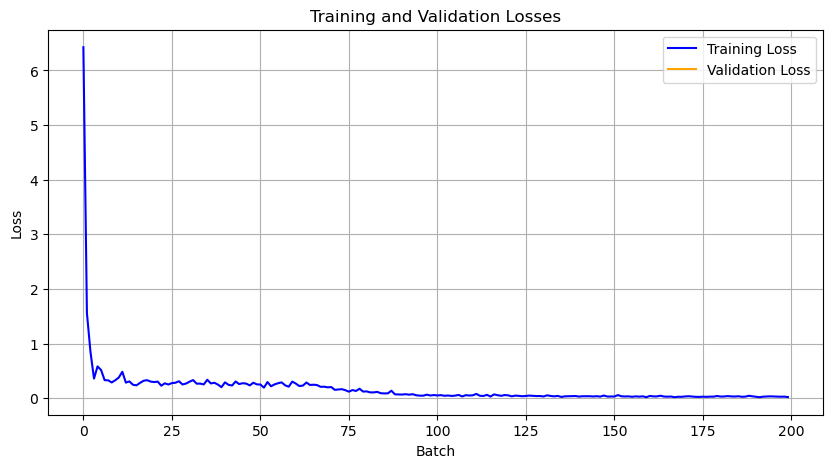

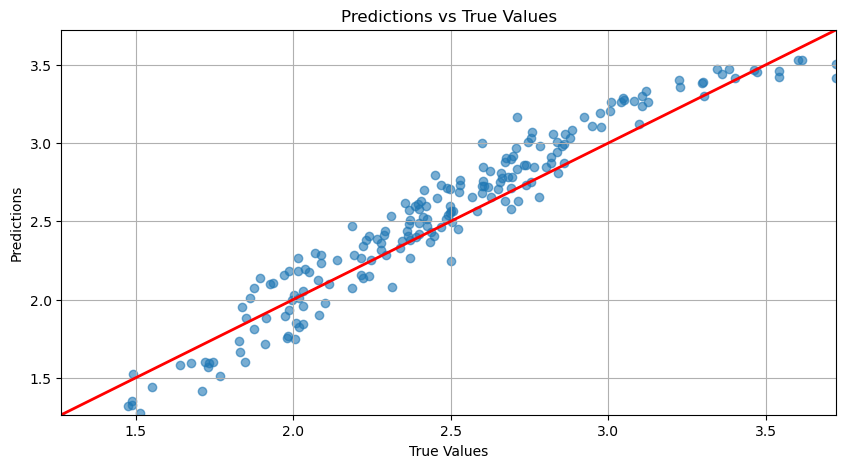

In [20]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pytorch_lightning as pl
import torch.nn as nn
import matplotlib.pyplot as plt

# Create synthetic dataset
def create_dataset(num_samples=1000, num_features=10):
    np.random.seed(42)
    X = np.random.rand(num_samples, num_features).astype(np.float32)
    y = np.dot(X, np.random.rand(num_features, 1)).flatten() + np.random.normal(0, 0.1, num_samples)
    return X, y

# Dataset class
class RegressionDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# Regression Model
class TransformerRegressionModel(pl.LightningModule):
    def __init__(self, num_features, num_heads=4, num_layers=2, d_model=64):
        super(TransformerRegressionModel, self).__init__()
        self.embedding = nn.Linear(num_features, d_model)
        self.transformer = nn.Transformer(d_model, nhead=num_heads, num_encoder_layers=num_layers)
        self.fc_out = nn.Linear(d_model, 1)
        self.criterion = nn.MSELoss()
        self.train_losses = []
        self.val_losses = []

    def forward(self, x):
        # Assuming the input x has shape (batch_size, seq_len, num_features)
        x = self.embedding(x)  # (batch_size, d_model)
        x = x.unsqueeze(1)  # (batch_size, 1, d_model)
        x = x.permute(1, 0, 2)  # Transform to (1, batch_size, d_model)
        x = self.transformer(x, x)  # Apply self-attention
        x = x.mean(dim=0)  # Pool along the sequence length dimension (aggregate features)
        return self.fc_out(x)
    
    def training_step(self, batch, batch_idx):
        features, targets = batch
        predictions = self(features)
        loss = self.criterion(predictions.flatten(), targets)
        self.log('train_loss', loss)
        self.train_losses.append(loss.item())  # Collect training losses
        return loss

    def validation_step(self, batch, batch_idx):
        features, targets = batch
        predictions = self(features)
        loss = self.criterion(predictions.flatten(), targets)
        self.log('val_loss', loss)
        self.val_losses.append(loss.item())  # Collect validation losses
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

# Create dataset and DataLoader
X, y = create_dataset()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_dataset = RegressionDataset(X_train, y_train)
test_dataset = RegressionDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

# Initialize the model
model = TransformerRegressionModel(num_features=X.shape[1])

# Set up the trainer
trainer = pl.Trainer(max_epochs=50,
                        # accelerator="gpu",
                        # devices="auto",
                        # precision="bf16-mixed"
                        )

# Train the model
trainer.fit(model, train_loader)

### Visualization Functions

def plot_losses(model):
    # Plot training and validation losses
    plt.figure(figsize=(10, 5))
    plt.plot(model.train_losses, label='Training Loss', color='blue')
    plt.plot(model.val_losses, label='Validation Loss', color='orange')
    plt.xlabel('Batch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Losses')
    plt.legend()
    plt.grid()
    plt.show()

def plot_predictions(model, test_loader):
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for features, targets in test_loader:
            predictions = model(features).detach().numpy()
            all_predictions.append(predictions)
            all_targets.append(targets.numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)

    plt.figure(figsize=(10, 5))
    plt.scatter(all_targets, all_predictions, alpha=0.6)
    plt.plot([min(all_targets), max(all_targets)], [min(all_targets), max(all_targets)], color='red', lw=2)  # Diagonal line
    plt.title('Predictions vs True Values')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.xlim([min(all_targets), max(all_targets)])
    plt.ylim([min(all_targets), max(all_targets)])
    plt.grid()
    plt.show()

# Call visualization functions after training
plot_losses(model)
plot_predictions(model, test_loader)